[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/18_compound_ai_evaluation/lab01_factorial_capstone_eval.ipynb)

# 🧪 Lab 01 — A Factorial Evaluation of the Capstone Assistant

> **Module:** Compound AI Evaluation · **Type:** Lab · **Estimated time:** 60–75 min · **Difficulty:** Intermediate–Advanced

NB 53 taught the method on Meridian's support bot. This lab points the same machinery at **your own capstone** — the AI Customer-Feedback Assistant from [NB 48](../15_capstones/48_capstone_ai_assistant.ipynb). The scenario: the capstone shipped, and three upgrade proposals are now sitting in sprint planning:

| Proposal | The knob | The catch |
|---|---|---|
| "Use the large model tier" | `model_tier: small → large` | **4× the price per call** |
| "Retrieve more context" | `retrieval_k: 2 → 5` | more input tokens |
| "Rewrite the RAG prompt" | `prompt_style: terse → detailed` | more input tokens |

In NB 53 the team shipped all three at once and needed forensics afterwards. Here you do it the right way round: **run the factorial experiment *before* the release** and ship only what the data supports. You'll build everything hands-on — this is a lab, so most of the code is yours to run, poke at, and extend.

**What you'll build:** a compact, deterministic rebuild of the capstone's answer pipeline with three genuinely quality-moving knobs → the full 2×2×2 factorial study with replication (800 judged runs) → a rubric judge → a single-run-instability demo → ANOVA attribution with an interaction and partial η² → a cost/quality Pareto frontier → an evidence-backed ship decision → the same study expressed as CAFE config.

## 🎯 Learning objectives

By the end of this lab you can:

1. Wrap an existing compound pipeline as the black-box `run(config, item)` contract a factorial study needs.
2. Turn three concrete upgrade proposals into **factors and levels** and enumerate the full design.
3. Run a replicated study and **demonstrate on your own data** why a single-replication comparison is untrustworthy.
4. Attribute quality to factors with **ANOVA** — p-values, partial η², and an interaction you can explain to a PM.
5. Read a **cost/quality Pareto frontier** and turn it into a ship/no-ship recommendation.
6. Express the whole study as a **CAFE** configuration.

> 📎 **100% offline.** Like NB 48 and NB 53, everything runs with a deterministic seeded mock — no API keys, no internet, no imports from outside this notebook. Swap the mock for a real provider via [`llm_providers.py`](../llm_providers.py) and the machinery is unchanged.

## 1. The system under test — your capstone, compacted

NB 48's assembly line has five stations: **Classify → Validate → Rules engine → RAG answer → Report**. All three upgrade proposals target one station — the **RAG answer** step (which docs get retrieved, which model reads them, what the prompt asks for). So that's where our factors will live; the other stations ride along unchanged.

That's a deliberate design decision worth naming: **a stage you hold fixed is a constant, not a confound.** The classifier and rules engine behave identically in every configuration, so they cannot explain any quality difference the experiment finds — which is exactly what lets us attribute differences to the three knobs.

We rebuild the capstone inline in compact form (same vendored-mock pattern NB 48 itself uses, so the lab is self-contained): the knowledge base, the keyword retrieval, a condensed classifier + priority engine, and a mock answer model whose behaviour *genuinely depends on the three knobs* — with seeded randomness on top, because a real LLM pipeline is a noisy instrument and the whole point of replication is to handle that.

In [1]:
import itertools
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

### The knowledge base and the eval set

The KB is NB 48's seven-document help manual, unchanged. The eval set is new — and it's the artefact you'd actually have to sit down and write for your own capstone: **20 inbox-style messages** in the voice of the capstone's overnight feedback (several are verbatim from NB 48's `FEEDBACK` list), each labelled with the KB doc that answers it and the **reference phrase** a correct answer must contain. That reference phrase is what the judge will look for.

In [2]:
# NB 48's knowledge base, verbatim — the assistant's help manual.
KB = [
    ("billing.refunds",
     "Refunds are issued within 5 business days. Request from the Billing page within 30 days of purchase."),
    ("billing.subscriptions",
     "Subscriptions renew automatically. Cancel from Settings → Billing → Cancel subscription. You retain access until period end."),
    ("billing.pricing",
     "Three tiers: Free, Pro $19/mo, Enterprise on request. Annual billing gives a 15% discount."),
    ("tech.password",
     "Use 'Forgot password' on the sign-in page. Reset emails arrive within 5 minutes; check spam."),
    ("tech.errors",
     "A 500 error usually indicates a temporary backend issue. Wait 60 seconds and retry. Contact support with the trace ID if persistent."),
    ("feature.exports",
     "CSV and JSON exports are on Pro plans. XLSX is on the roadmap."),
    ("feature.integrations",
     "Slack, Microsoft Teams, and Zapier are supported. Okta SSO is Enterprise-only."),
]
KB_DICT = dict(KB)

# The eval set: (gold KB doc, inbox message, reference phrase a correct answer must contain).
EVAL_SET = [
    ("billing.refunds",       "My invoice doesn't match my plan, please refund the difference of $45.", "5 business days"),
    ("billing.refunds",       "Any update on the request I sent last week about my money back?",        "5 business days"),
    ("billing.refunds",       "I want a full refund. This is unacceptable.",                            "5 business days"),
    ("billing.subscriptions", "How do I cancel? The button is hidden.",                                 "Settings → Billing"),
    ("billing.subscriptions", "Charged twice for my subscription last month.",                          "Settings → Billing"),
    ("billing.subscriptions", "I can't find where to cancel — the page hides the button.",              "Settings → Billing"),
    ("billing.pricing",       "Why is the annual renewal so expensive? I'm on the top plan.",           "15% discount"),
    ("billing.pricing",       "Annual discount doesn't apply on my account.",                           "15% discount"),
    ("billing.pricing",       "Pricing page is confusing.",                                             "15% discount"),
    ("tech.password",         "Password reset email never arrives.",                                    "check spam"),
    ("tech.password",         "Login keeps logging me out after 5 minutes.",                            "check spam"),
    ("tech.errors",           "500 error on file upload. Help.",                                        "60 seconds"),
    ("tech.errors",           "The webhook endpoint returns 500 randomly.",                             "60 seconds"),
    ("tech.errors",           "Stuck at the loading page, can't access my data on the app.",            "60 seconds"),
    ("feature.exports",       "Could you please add CSV export? I really need it for my reports.",      "Pro plans"),
    ("feature.exports",       "Can you add a CSV export for the analytics page?",                       "Pro plans"),
    ("feature.exports",       "Latest patch broke the export feature.",                                 "Pro plans"),
    ("feature.integrations",  "Could you support SSO with Okta?",                                       "Enterprise-only"),
    ("feature.integrations",  "Could you support a Zapier integration?",                                "Enterprise-only"),
    ("feature.integrations",  "Slack integration would be a game changer.",                             "Enterprise-only"),
]
print(f"{len(KB)} KB docs, {len(EVAL_SET)} eval messages")

7 KB docs, 20 eval messages


### Retrieval — where `retrieval_k` bites

Retrieval is NB 48's `keyword_score`/`retrieve` pair, with `k` promoted from a hard-coded default to a **factor**. And exactly as in NB 53, keyword retrieval is *genuinely imperfect* — customers say "money back" while the doc says "Refunds", so for several messages the right doc is ranked 3rd–5th, behind docs that happen to share words like *page* or *on*. That vocabulary mismatch is precisely what a deeper `k` buys its way out of: a doc at rank 4 is missed at `k=2` and found at `k=5`. Two messages never match their doc at all — no `k` can save those.

In [3]:
def keyword_score(query, doc_text):
    q = set(re.findall(r"[a-z']+", query.lower()))
    d = set(re.findall(r"[a-z']+", doc_text.lower()))
    return len(q & d)

def retrieve(query, k):
    """NB 48's retrieval, with k as an experimental factor instead of a default."""
    scored = sorted(((keyword_score(query, t), n) for n, t in KB), reverse=True)
    return [n for s, n in scored[:k] if s > 0]

# Where does each message's gold doc actually rank?
rank_rows = []
for topic, msg, _ in EVAL_SET:
    scored = sorted(((keyword_score(msg, t), n) for n, t in KB), reverse=True)
    names = [n for s, n in scored if s > 0]
    rank = names.index(topic) + 1 if topic in names else None
    rank_rows.append({"gold_doc": topic, "rank": rank, "message": msg[:52]})
pd.DataFrame(rank_rows)

,gold_doc,rank,message
0,billing.refunds,1.0,"My invoice doesn't match my plan, please refun..."
1,billing.refunds,3.0,Any update on the request I sent last week abo...
2,billing.refunds,NaN,I want a full refund. This is unacceptable.
3,billing.subscriptions,5.0,How do I cancel? The button is hidden.
4,billing.subscriptions,1.0,Charged twice for my subscription last month.
5,billing.subscriptions,5.0,I can't find where to cancel — the page hides ...
6,billing.pricing,3.0,Why is the annual renewal so expensive? I'm on...
7,billing.pricing,1.0,Annual discount doesn't apply on my account.
8,billing.pricing,NaN,Pricing page is confusing.
9,tech.password,1.0,Password reset email never arrives.


---

### ✋ Quick exercise (~2 min) — Price the two retrieval levels

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Before running any model calls, you can already measure the **retrieval hit rate** each level of `retrieval_k` delivers: for how many of the 20 messages is the gold doc inside the retrieved top-k? Compute it for `k=2` and `k=5`.

In [4]:
# ✍️ Your turn 👇
# For each k in (2, 5): count messages whose gold doc is in retrieve(message, k).
hit_rate_k2 = ...
hit_rate_k5 = ...
print(hit_rate_k2, hit_rate_k5)

Ellipsis Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
hits = {k: sum(topic in retrieve(msg, k) for topic, msg, _ in EVAL_SET) for k in (2, 5)}
hit_rate_k2 = hits[2] / len(EVAL_SET)
hit_rate_k5 = hits[5] / len(EVAL_SET)
print(hit_rate_k2, hit_rate_k5)   # 0.55 vs 0.90
```

`k=2` finds the right doc for **11/20 (55%)** of messages; `k=5` for **18/20 (90%)**. That's a big mechanical difference — but it is *not yet* a quality difference: whether those extra hits turn into better answers depends on what the model does with a context that now also contains up to four irrelevant docs. That's exactly the kind of "it depends" the factorial experiment is built to resolve.
</details>

### The rest of the belt, condensed — and the answer station's knobs

Below: NB 48's classifier + priority engine boiled down to a few lines (deterministic, so they add no noise), and the **mock answer model**. The mock is rigged the way real pipelines behave, and this rigging is the ground truth the experiment should rediscover:

- **The right doc in context is everything** — with it, correctness probability is high; without it the model falls back on parametric guessing.
- **The large tier is better at both** — reading context *and* guessing without it — and shrugs off irrelevant docs.
- **The small tier gets confused by clutter**: every irrelevant doc in the context costs it correctness (the classic "lost in the middle" failure).
- **The detailed prompt helps only when there's a right doc to ground on.**
- On top: **seeded randomness**, because two identical calls to a real LLM do not return identical answers.

We rig it, then check whether the machinery recovers what we injected — the same sanity-check pattern NB 53 recommends before spending real API money on a study.

In [5]:
# --- NB 48's Station 1 + 3, condensed (deterministic ⇒ no noise added) -------
POSITIVE = {"love", "great", "amazing", "excellent", "happy", "fantastic",
            "perfect", "delight", "smooth", "fast", "thank", "good"}
NEGATIVE = {"hate", "terrible", "awful", "bad", "slow", "broken", "bug",
            "crash", "angry", "frustrating", "refund", "cancel", "worst"}
TOPIC_VOCAB = {"billing": {"refund", "invoice", "charge", "bill", "subscription", "renew", "payment", "price"},
               "tech":    {"error", "crash", "bug", "broken", "login", "password", "loading", "freeze", "stuck"},
               "feature": {"feature", "request", "missing", "wish", "add", "support"}}

def classify(text):
    words = set(re.findall(r"[a-z']+", text.lower()))
    pos, neg = len(words & POSITIVE), len(words & NEGATIVE)
    sentiment = "positive" if pos > neg else "negative" if neg > pos else "neutral"
    scores = {t: len(words & v) for t, v in TOPIC_VOCAB.items()}
    topic = max(scores, key=scores.get) if max(scores.values()) > 0 else "other"
    return sentiment, topic

def priority(text, sentiment, topic):
    if any(w in text.lower() for w in ("urgent", "security", "lawyer", "escalate", "asap")):
        return "p0_escalate"
    if sentiment == "negative" and topic in {"billing", "tech"}:
        return "p1_negative"
    return "p2_route" if topic == "feature" else "p3_acknowledge"

# --- Station 4: the mock answer model — where all three knobs bite -----------
P_HIT  = {"small": 0.60, "large": 0.85}     # P(correct) when the gold doc is in context
P_MISS = {"small": 0.10, "large": 0.28}     # parametric guessing without it
DETAILED_BONUS = 0.12                       # detailed prompt, only when grounded
DISTRACTOR_PENALTY = {"small": 0.08, "large": 0.0}   # per irrelevant doc in context

def mock_answer(tier, prompt_style, context_topics, gold_topic, rng):
    """Offline stand-in for the RAG answer call (the NB 27–48 MockLLM pattern)."""
    if gold_topic in context_topics:
        p = P_HIT[tier]
        if prompt_style == "detailed":
            p += DETAILED_BONUS
        p -= DISTRACTOR_PENALTY[tier] * (len(context_topics) - 1)
    else:
        p = P_MISS[tier]
    p = float(np.clip(p, 0.02, 0.98))

    roll = rng.random()
    if roll < p:                                    # correct, grounded answer
        return f"According to our docs: {KB_DICT[gold_topic]}"
    if roll < p + 0.25:                             # vague deflection
        return "Thanks for reaching out — please check the relevant help page."
    wrong = [t for t, _ in KB if t != gold_topic]   # confidently wrong
    return f"According to our docs: {KB_DICT[wrong[int(rng.integers(len(wrong)))]]}"

# --- Per-call cost in credit units (log real tokens/latency in production) ---
MODEL_COST   = {"small": 0.25, "large": 1.0}        # the 4× the CFO is asking about
PROMPT_COST  = {"terse": 0.0, "detailed": 0.08}
COST_PER_DOC = 0.04

def run_config(config, item, rng):
    """The black-box contract a factorial study needs: run(config, item) → output."""
    gold_topic, message, _reference = item
    sentiment, topic = classify(message)             # Station 1 (fixed)
    prio = priority(message, sentiment, topic)       # Station 3 (fixed)
    context = retrieve(message, config["retrieval_k"])
    answer = mock_answer(config["model_tier"], config["prompt_style"], context, gold_topic, rng)
    cost = (MODEL_COST[config["model_tier"]] + PROMPT_COST[config["prompt_style"]]
            + COST_PER_DOC * len(context))
    return {"answer": answer, "priority": prio, "cost": cost}

demo_rng = np.random.default_rng(seed=1)
demo_cfg = {"prompt_style": "detailed", "retrieval_k": 5, "model_tier": "large"}
demo = run_config(demo_cfg, EVAL_SET[0], demo_rng)
print(f"[{demo['priority']}] {demo['answer']}\n(cost: {demo['cost']:.2f} credits)")

[p1_negative] According to our docs: Refunds are issued within 5 business days. Request from the Billing page within 30 days of purchase.
(cost: 1.24 credits)


## 2. The design — three proposals become a 2×2×2 grid

Each sprint-planning proposal is a **factor**; its status-quo and proposed settings are the **levels**; a full assignment is a **configuration** — one shippable version of the assistant. Three binary factors ⇒ 2 × 2 × 2 = **8 configurations**, and `itertools.product` is the entire design-generation step:

In [6]:
FACTORS = {
    "prompt_style": ["terse", "detailed"],
    "retrieval_k":  [2, 5],
    "model_tier":   ["small", "large"],
}
CFG_COLS = list(FACTORS)

configs = [dict(zip(FACTORS, combo)) for combo in itertools.product(*FACTORS.values())]
pd.DataFrame(configs)

,prompt_style,retrieval_k,model_tier
0,terse,2,small
1,terse,2,large
2,terse,5,small
3,terse,5,large
4,detailed,2,small
5,detailed,2,large
6,detailed,5,small
7,detailed,5,large


---

### ✋ Quick exercise (~2 min) — Budget the study before you run it

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

We'll run every configuration on all 20 messages with **5 replications**. Compute (a) the total number of judged pipeline runs, and (b) an *upper bound* on the study's cost in credits, assuming every run were as expensive as the priciest possible configuration (large tier, detailed prompt, 5 docs retrieved). Would you sign off on this budget before an experiment against a real API?

In [7]:
# ✍️ Your turn 👇
REPLICATIONS = 5
n_runs = ...
max_cost_per_run = ...
budget_bound = ...
print(n_runs, max_cost_per_run, budget_bound)

Ellipsis Ellipsis Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
REPLICATIONS = 5
n_runs = len(configs) * len(EVAL_SET) * REPLICATIONS          # 8 × 20 × 5 = 800
max_cost_per_run = MODEL_COST["large"] + PROMPT_COST["detailed"] + COST_PER_DOC * 5   # 1.28
budget_bound = n_runs * max_cost_per_run                       # 1024 credits
print(n_runs, max_cost_per_run, budget_bound)
```

**800 judged runs, at most 1,024 credits** (the real total will be lower — half the runs use the small tier). This do-the-arithmetic-first step is not busywork: against a real API, 800 runs × (pipeline call + judge call) is a bill you want to have *chosen*, not discovered. It's also the number that motivates fractional designs when the grid grows (NB 53 §8).
</details>

## 3. The judge — NB 53's rubric, pointed at the capstone

Same 0–3 correctness rubric as NB 53 (the shape of CAFE's `CORRECTNESS_0_3`), same offline keyword judge: **3** if the answer contains the reference phrase, **1** for the vague deflection, **0** for wrong or misleading. It never awards a 2 — a real LLM judge uses the full scale, and both the ordinal caveat and the judge-validation duty (Krippendorff's α against human raters) from NB 53 §4 apply verbatim here.

In [8]:
def keyword_judge(answer, reference):
    """Offline judge: 3 = contains the reference phrase, 1 = vague deflection, 0 = wrong."""
    if reference.lower() in answer.lower():
        return 3
    if "check the relevant help page" in answer.lower():
        return 1
    return 0

print(keyword_judge(demo["answer"], EVAL_SET[0][2]))   # the §1 demo answer

3


## 4. Run the study — 8 configs × 20 messages × 5 replicates

Now the actual experiment: every configuration, every message, five times. One seeded generator drives all 800 runs, so the whole study is exactly reproducible — rerun the notebook and you get the same 800 scores.

In [9]:
REPLICATIONS = 5
rng = np.random.default_rng(seed=0)

rows = []
for cfg in configs:
    for qid, item in enumerate(EVAL_SET):
        for rep in range(REPLICATIONS):
            out = run_config(cfg, item, rng)
            rows.append({**cfg, "qid": f"q{qid:02d}", "rep": rep,
                         "score": keyword_judge(out["answer"], item[2]),
                         "cost": out["cost"]})

results = pd.DataFrame(rows)
print(f"{len(results)} judged runs")
results.head()

800 judged runs


,prompt_style,retrieval_k,model_tier,qid,rep,score,cost
0,terse,2,small,q00,0,1,0.33
1,terse,2,small,q00,1,3,0.33
2,terse,2,small,q00,2,3,0.33
3,terse,2,small,q00,3,3,0.33
4,terse,2,small,q00,4,0,0.33


mean   std
prompt_style retrieval_k model_tier            
detailed     5           large       2.76  0.74
terse        5           large       2.62  0.83
detailed     2           large       2.15  1.25
terse        2           large       1.82  1.31
detailed     5           small       1.59  1.33
             2           small       1.48  1.37
terse        5           small       1.21  1.32
             2           small       1.10  1.28

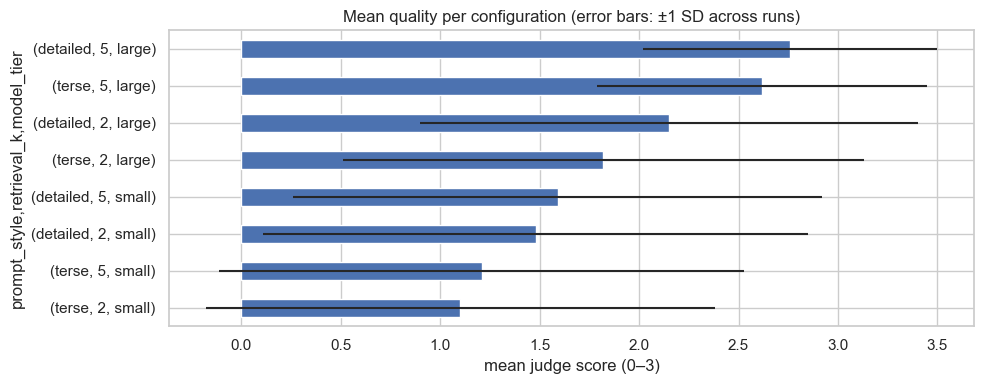

In [10]:
config_means = (results.groupby(CFG_COLS)["score"].agg(["mean", "std"])
                .sort_values("mean", ascending=False).round(2))

ax = config_means["mean"].plot.barh(xerr=config_means["std"], color="#4c72b0")
ax.set_xlabel("mean judge score (0–3)")
ax.set_title("Mean quality per configuration (error bars: ±1 SD across runs)")
ax.invert_yaxis()
plt.tight_layout()
config_means

A clean gradient: every `large` config beats every `small` config, and within each tier deeper retrieval and the detailed prompt help. The top config (`detailed / 5 / large`, mean **2.76**) leads the runner-up (`terse / 5 / large`, **2.62**) by just **0.14** — while the standard deviations sit around **0.7–1.4**. Gap ≪ noise: exactly the situation where a lazy comparison lies to you.

## 5. The single-run trap — would one replication have told the truth?

Pretend budget pressure had won and you'd run each configuration only once per message. Each `rep` column value is one such complete single-replication study — we ran five of them. Do they agree on the winner?

In [11]:
fmt = lambda t: "/".join(map(str, t))                     # ('terse', 5, 'large') → 'terse/5/large'

winner_all = results.groupby(CFG_COLS)["score"].mean().idxmax()
winners_by_rep = (results.groupby("rep")
                  .apply(lambda d: d.groupby(CFG_COLS)["score"].mean().idxmax(),
                         include_groups=False))

print("Winner using ALL replications :", fmt(winner_all))
print("\nWinner per single-replication study:")
print(winners_by_rep.map(fmt).to_string())
print(f"\n{winners_by_rep.nunique()} different configs claim the crown across "
      f"{REPLICATIONS} single-replication studies.")

Winner using ALL replications : detailed/5/large

Winner per single-replication study:
rep
0    detailed/5/large
1       terse/5/large
2    detailed/5/large
3       terse/5/large
4    detailed/5/large

2 different configs claim the crown across 5 single-replication studies.


Same pipeline, same messages, same judge — and the single-replication studies **don't agree on the winner**: some crown `detailed/5/large`, others `terse/5/large`. Either one would have gone into the sprint review as "the best config" with nobody the wiser. Whatever the two configs' true ordering, one run per config cannot resolve a 0.14 gap under this much noise — that takes replication plus the significance tests of the next section.

---

### ✋ Quick exercise (~2 min) — How much does one config's score swing?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Flipping winners is one symptom; here's the underlying disease. Filter `results` to the all-replication winner (`winner_all` — note it's a tuple aligned with `CFG_COLS`), compute its mean score *within each replication*, and compare the swing (max − min) to the 0.14 gap that separates it from the runner-up.

In [12]:
# ✍️ Your turn 👇
winner_rows = ...
per_rep = ...
print(per_rep)

Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
mask = (results[CFG_COLS] == pd.Series(winner_all, index=CFG_COLS)).all(axis=1)
winner_rows = results[mask]
per_rep = winner_rows.groupby("rep")["score"].mean()
print(per_rep)
print(f"swing: {per_rep.max() - per_rep.min():.2f}  vs  gap to runner-up: 0.14")
```

The winner's measured quality swings between **2.65 and 2.90** across replications — a swing of **0.25**, nearly twice the 0.14 gap to the runner-up. When a config's score moves more between *identical* studies than it differs from its rival, single-run rankings are noise wearing a suit.
</details>

## 6. Attribution — which proposal actually moves quality?

The config table ranks *versions*; sprint planning needs a verdict per *proposal*. That's ANOVA's job, and the two modelling moves from NB 53 §6 carry over unchanged:

1. **Block on the message** (`C(qid)`): inbox messages differ wildly in difficulty ("Pricing page is confusing." is unanswerable by design), and every config saw the same 20 — soaking up that variance sharpens every factor test.
2. **Include the interaction we suspect**: §1's quick exercise showed `k=5` mostly rescues docs from ranks 3–5 — but whether a *fuller* context helps depends on the model reading it. So we fit `retrieval_k × model_tier`.

In [13]:
ols = smf.ols("score ~ C(retrieval_k) * C(model_tier) + C(prompt_style) + C(qid)",
              data=results).fit()
anova = sm.stats.anova_lm(ols, typ=2)
anova["partial_eta_sq"] = anova["sum_sq"] / (anova["sum_sq"] + anova.loc["Residual", "sum_sq"])
anova.round(4)

,sum_sq,df,F,PR(>F),partial_eta_sq
C(retrieval_k),33.2113,1.0,30.0271,0.0000,0.0373
C(model_tier),197.0113,1.0,178.1225,0.0000,0.1867
C(prompt_style),18.9113,1.0,17.0981,0.0000,0.0216
C(qid),287.7137,19.0,13.6910,0.0000,0.2511
C(retrieval_k):C(model_tier),17.7012,1.0,16.0041,0.0001,0.0202
Residual,858.2900,776.0,NaN,NaN,0.5000


Reading it like NB 53 taught you — `PR(>F)` for *is it real?*, `partial_eta_sq` for *how big?*: **all three factors and the interaction are significant** (every p ≤ 0.0001). The effect-size ranking: `model_tier` (η² ≈ 0.19, large) towers over `retrieval_k` (≈ 0.04) and `prompt_style` (≈ 0.02, both small-to-medium) — and note `C(qid)` at η² ≈ 0.25: *which message you ask* explains more variance than any knob, which is precisely why we blocked on it.

Now the directions and magnitudes in score units — and the cell means that unpack the interaction:

In [14]:
for f in CFG_COLS:
    levels = results.groupby(f)["score"].mean()
    print(f"{f:>13}: " + "  vs  ".join(f"{lv}={m:.2f}" for lv, m in levels.items())
          + f"   (Δ = {levels.max() - levels.min():+.2f})")

print("\nretrieval_k × model_tier cell means:")
print(results.pivot_table(index="retrieval_k", columns="model_tier",
                          values="score", aggfunc="mean").round(2))

 prompt_style: detailed=2.00  vs  terse=1.69   (Δ = +0.31)
  retrieval_k: 2=1.64  vs  5=2.04   (Δ = +0.41)
   model_tier: large=2.34  vs  small=1.34   (Δ = +0.99)

retrieval_k × model_tier cell means:
model_tier   large  small
retrieval_k              
2             1.98   1.29
5             2.69   1.40


The verdict to bring to sprint planning:

- **The 4× model tier is the star** — +0.99 score points, by far the largest effect. Unlike NB 53's Meridian study (where retrieval largely *substituted* for the big model), your capstone's expensive model is genuinely load-bearing. Same method, opposite verdict — which is exactly why you run the experiment instead of recycling the last project's conclusion.
- **Deeper retrieval works — but only with the large tier.** Read the cell means: going `k=2 → 5` lifts the large tier by **+0.71** but the small tier by only **+0.11**. The small model finds more right docs *and* drowns in the extra clutter; the net is a wash. That's the significant interaction, and it kills the tempting cost-saving idea "ship k=5 with the small model and skip the tier upgrade."
- **The detailed prompt is a small, real, nearly-free win** (+0.31 on average).

And the rigging check: we injected *tier > k > prompt, with k's payoff gated on tier* — the ANOVA recovered every piece of it. The harness works; now you could point it at a real API with a clear conscience.

---

### ✋ Quick exercise (~2 min) — The one-line answer for the PM

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

From the `anova` table: print the factor rows sorted by `partial_eta_sq` (drop `Residual`), and compute — in code — whether the `retrieval_k × model_tier` interaction is significant at α = 0.05.

In [15]:
# ✍️ Your turn 👇
ranked = ...
interaction_significant = ...
print(ranked)
print("interaction significant:", interaction_significant)

Ellipsis
interaction significant: Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
ranked = anova.drop(index="Residual").sort_values("partial_eta_sq", ascending=False)
interaction_significant = anova.loc["C(retrieval_k):C(model_tier)", "PR(>F)"] < 0.05
print(ranked[["PR(>F)", "partial_eta_sq"]])
print("interaction significant:", interaction_significant)
```

`C(qid)` and `C(model_tier)` top the ranking, and the interaction is **significant** (p ≈ 0.0001). So the honest one-liner for the PM is a conditional: *"the tier upgrade is the big win, and deeper retrieval is worth it — but only if we take the tier upgrade too."*
</details>

## 7. Money — the cost/quality Pareto frontier

Every run logged its cost, so the same 800 rows answer the CFO's half of the question. A config is **Pareto-optimal** if nothing else is both cheaper and better; everything off the frontier is a config nobody should ever run.

In [16]:
summary = (results.groupby(CFG_COLS, as_index=False)
           .agg(quality=("score", "mean"), cost=("cost", "mean")))

def pareto_frontier(df, cost_col="cost", quality_col="quality"):
    """Rows not dominated by any cheaper-and-better row."""
    frontier, best = [], -np.inf
    for _, row in df.sort_values([cost_col, quality_col], ascending=[True, False]).iterrows():
        if row[quality_col] > best:
            frontier.append(row)
            best = row[quality_col]
    return pd.DataFrame(frontier)

frontier = pareto_frontier(summary)
frontier.round(2)

,prompt_style,retrieval_k,model_tier,quality,cost
5,terse,2,small,1.10,0.32
7,terse,5,small,1.21,0.39
1,detailed,2,small,1.48,0.40
3,detailed,5,small,1.59,0.47
4,terse,2,large,1.82,1.07
6,terse,5,large,2.62,1.14
2,detailed,5,large,2.76,1.22


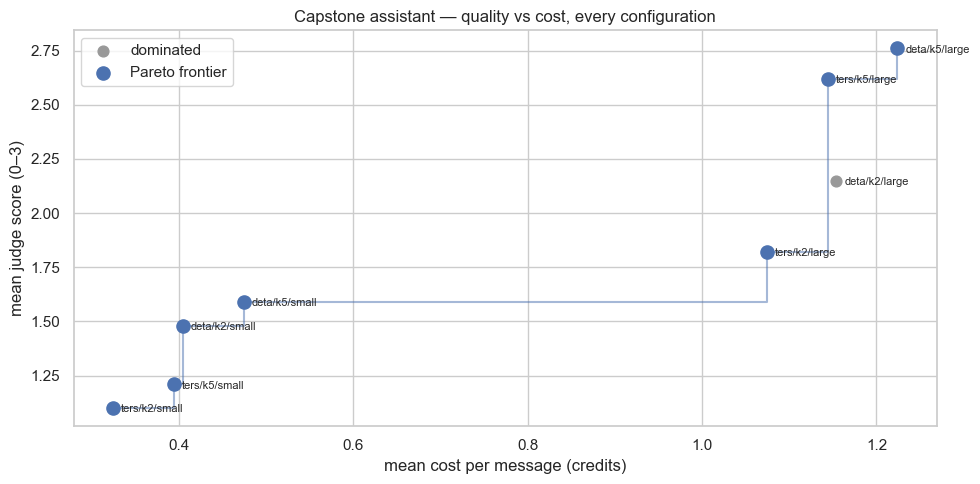

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(summary["cost"], summary["quality"], s=60, color="#999999", label="dominated")
ax.scatter(frontier["cost"], frontier["quality"], s=90, color="#4c72b0", zorder=3,
           label="Pareto frontier")
ax.step(frontier["cost"], frontier["quality"], where="post", color="#4c72b0", alpha=0.5)
for _, r in summary.iterrows():
    ax.annotate(f"{r.prompt_style[:4]}/k{r.retrieval_k}/{r.model_tier}",
                (r.cost, r.quality), textcoords="offset points", xytext=(6, -3), fontsize=8)
ax.set_xlabel("mean cost per message (credits)")
ax.set_ylabel("mean judge score (0–3)")
ax.set_title("Capstone assistant — quality vs cost, every configuration")
ax.legend()
plt.tight_layout()

Three readings off this chart:

- **The frontier has a cliff, not a slope.** The four small-tier configs cluster at 0.32–0.47 credits and quality ≤ 1.59; the large-tier configs sit at ~1.07–1.22 credits and 1.82–2.76. There is no mid-priced option — the experiment tells you this is a *buy the tier or don't* decision.
- **The best deal in the grid hides inside the large tier:** `terse/k2/large → terse/k5/large` buys **+0.80** quality for **+0.07** credits. Compare that to the detailed prompt's +0.14 for +0.08 at k=5 — same price, a fraction of the lift.
- **One config is strictly dominated:** `detailed/k2/large` (2.15 at ≈1.15 credits) — `terse/k5/large` is cheaper *and* far better. Spending on adjectives while starving the model of context is provably a mistake, and this chart is the proof you attach to the sprint ticket.

## 8. The decision — what would you ship?

A frontier is a menu, not a decision. The last step is to name a policy and let the data pick the config. Three policies a real team would weigh:

In [18]:
best = summary.sort_values("quality", ascending=False).iloc[0]

# Value pick: the cheapest config within 0.2 score points of the best.
value = (frontier[frontier["quality"] >= best["quality"] - 0.20]
         .nsmallest(1, "cost").iloc[0])

# Budget pick: the best you can do at ≤ 0.60 credits/message.
budget = (summary[summary["cost"] <= 0.60]
          .sort_values("quality", ascending=False).iloc[0])

decision = pd.DataFrame([best, value, budget],
                        index=["🏆 max quality", "⚖️ value (within 0.2 of best)", "💰 budget (≤ 0.60 cr)"])
decision.round(2)

,prompt_style,retrieval_k,model_tier,quality,cost
🏆 max quality,detailed,5,large,2.76,1.22
⚖️ value (within 0.2 of best),terse,5,large,2.62,1.14
💰 budget (≤ 0.60 cr),detailed,5,small,1.59,0.47


**Our call: ship `terse / k=5 / large`** — the value pick. It concedes 0.14 quality (within the noise we measured in §5) and saves the detailed prompt's token overhead; take the prompt rewrite later as a free-standing A/B if the PM wants the last nibble. The two proposals that survive are the *expensive* one (tier — the data says it's load-bearing) and the *cheap* one (k=5 — the data says it's the best deal in the grid, conditional on the tier). If finance vetoes the tier entirely, the honest answer is the budget pick at **1.59** — and the experiment lets you tell them exactly what the veto costs: **−1.17** score points per message.

That sentence — *ship X, because factor A is load-bearing (p < 0.001, η² = 0.19), B only pays conditional on A (interaction p ≈ 0.0001), C is optional; the veto costs 1.17 points* — is the entire deliverable of a factorial evaluation. Not a vibe, a measurement.

## 9. The same study as CAFE config

Everything above was the hand-rolled loop; here's the study expressed in **[CAFE](https://github.com/fabian-lu/Cafe)**, mapping each piece you built onto its library counterpart (NB 53 §8 has the full tour):

| You hand-rolled (this lab) | CAFE |
|---|---|
| `FACTORS` + `itertools.product` | `factors=[...]` → full/fractional designs |
| `run_config(config, item, rng)` | the black-box `run(config, item)` contract |
| `keyword_judge` + reference phrases | `cafe.LLMJudge(model=...)` + `cafe.rubrics.CORRECTNESS_0_3` |
| the triple `for` loop, seed 0 | `replications=5` — concurrent, crash-safe, resumable |
| OLS ANOVA + partial η² | scale-matched mixed-effects models (ordinal → CLMM via R) |
| `pareto_frontier()` | automatic Pareto frontier over quality vs cost/latency/tokens |

The cell below is the library's keyless quick-start pattern and only runs if you've installed `cafe-core` (Python ≥ 3.11 + R — install instructions in NB 53 §8 or the [module README](README.md)); otherwise it skips gracefully and the code is worth reading either way.

In [19]:
try:
    import cafe
    CAFE_AVAILABLE = True
except ImportError:
    CAFE_AVAILABLE = False
    print("cafe-core not installed — the study below becomes a no-op (install it + R to run for real).")

if CAFE_AVAILABLE:
    pipe = cafe.Pipeline()

    @pipe.technique("retrieval_k", "k2")
    async def retrieve_2(ctx, query):
        return retrieve(query, 2)

    @pipe.technique("retrieval_k", "k5")
    async def retrieve_5(ctx, query):
        return retrieve(query, 5)

    @pipe.technique("answer", "small")
    async def small_tier(ctx, query, context=None):
        return mock_answer("small", "terse", context or [], ctx.item["topic"],
                           np.random.default_rng(0))

    @pipe.technique("answer", "large")
    async def large_tier(ctx, query, context=None):
        return mock_answer("large", "terse", context or [], ctx.item["topic"],
                           np.random.default_rng(0))

    @pipe.compose
    async def run(config, item, ctx):
        docs = await ctx.run("retrieval_k", query=item["text"])
        return await ctx.run("answer", query=item["text"], context=docs)

    class KeywordJudge:                      # this lab's judge, in CAFE's interface
        model = "keyword-match"
        async def score(self, rubric, question, answer, reference=None):
            v = keyword_judge(str(answer), reference or "")
            return cafe.JudgeOutput(value=v, value_numeric=v, reasoning="",
                                    prompt="", raw_response=str(v))

    study = cafe.Study(
        name="capstone-feedback-assistant",
        system=pipe,
        factors=[pipe.factor("retrieval_k"), pipe.factor("answer")],
        dataset=[{"text": m, "reference": r, "topic": t} for t, m, r in EVAL_SET],
        rubric=cafe.rubrics.CORRECTNESS_0_3,
        judge=KeywordJudge(),
        replications=5,
    )
    print(study.evaluate().report())         # means, significance, effect sizes — CLMM via R
else:
    print("Skipped (cafe-core not installed).")

cafe-core not installed — the study below becomes a no-op (install it + R to run for real).
Skipped (cafe-core not installed).


For the real thing you swap two pieces: the technique bodies become actual model calls (via [`llm_providers.py`](../llm_providers.py) or `cafe.complete(...)`), and the judge becomes `cafe.LLMJudge(model=...)`. The design, replication, statistics, and frontier come for free — which is the point: the statistics stop being the bottleneck, so the experiment actually gets run.

---

## 🧪 Practice exercises

Work these in order — each has a worked solution, but wrestle first.

### Exercise 1 — The scale-correct check: pass/fail + logistic

NB 53 warned that treating the ordinal 0–3 rubric as a number line is an assumption. Stress-test today's conclusions: collapse the score to binary (`passed = score == 3`), refit with `smf.logit` (same formula shape, including `C(qid)`), and compare the factor story — signs, relative magnitudes, and whether the interaction survives — to the OLS ANOVA's.

<details>
<summary>💡 <b>Solution</b></summary>

```python
d = results.assign(passed=(results["score"] == 3).astype(int))
logit = smf.logit("passed ~ C(retrieval_k) * C(model_tier) + C(prompt_style) + C(qid)",
                  data=d).fit(disp=0)
print(logit.summary2().tables[1]
      .loc[[i for i in logit.params.index if "qid" not in i]].round(3))
print(d.groupby("model_tier")["passed"].mean().round(2))
```

Same story, new scale: pass rates are 73% (large) vs 38% (small), 62% (k=5) vs 48% (k=2), 61% (detailed) vs 49% (terse). In log-odds, `k=5` adds ≈ +1.97 for the large tier, the small tier sits ≈ −1.34 below large, and the `k5 × small` interaction ≈ −1.80 wipes out almost the entire retrieval benefit for the small model — the same "k only pays with the big tier" verdict, now from a model that respects the outcome's scale. When both analyses agree, report either; when they disagree, trust the scale-correct one (that's CAFE's CLMM/logistic feature in miniature).
</details>

### Exercise 2 — 🐞 Debug me: the free replications

A teammate wants the §6 significance tests without paying for 800 runs. Their "optimisation" runs each config once and reuses the rows:

```python
# 🐞 What's wrong here?
single = results[results["rep"] == 0]           # run everything once: 160 runs
cheap = pd.concat([single] * 5, ignore_index=True)   # "replicate" for free 🎉
ols_cheap = smf.ols("score ~ C(retrieval_k) * C(model_tier) + C(prompt_style) + C(qid)",
                    data=cheap).fit()
print(sm.stats.anova_lm(ols_cheap, typ=2))      # everything's significant! ship it!
```

The code runs, the table looks great, everything is "significant". Why is every p-value in it a lie?

<details>
<summary>💡 <b>Solution</b></summary>

```python
# Copying rows is not replication. The F-test compares factor variance to
# RESIDUAL variance with n=800 worth of degrees of freedom — but there are only
# 160 independent observations; the other 640 are photocopies that add zero new
# information while shrinking the standard errors by √5. Compare honestly:
for name, d in [("honest 160-run study", single), ("photocopied '800'", cheap)]:
    a = sm.stats.anova_lm(smf.ols("score ~ C(retrieval_k) * C(model_tier)"
                                  " + C(prompt_style) + C(qid)", data=d).fit(), typ=2)
    print(name, " prompt p =", round(a.loc["C(prompt_style)", "PR(>F)"], 4),
          " k p =", round(a.loc["C(retrieval_k)", "PR(>F)"], 4))
```

With this seed the honest 160-run study gives `prompt_style` p ≈ 0.26 and even `retrieval_k` p ≈ 0.05 — the single-rep study genuinely *cannot* establish what the copies "prove". Replication means **new pipeline runs with fresh randomness**, because what it buys is an estimate of the run-to-run noise; duplicated rows contain none. The same trap in the wild: judging the same cached answer five times, or averaging five judge calls on one generation and calling it five replicates.
</details>

### Exercise 3 — The CFO's counter-offer

Finance replies to §8: *"0.60 credits per message, hard cap. What's the best we can do, and what does the cap cost us?"* Answer both questions from `summary` — no new runs needed — and state which of the three factors the cap effectively decides for you.

<details>
<summary>💡 <b>Solution</b></summary>

```python
capped = summary[summary["cost"] <= 0.60]
best_capped = capped.sort_values("quality", ascending=False).iloc[0]
print(best_capped)
print(f"cost of the cap: {summary['quality'].max() - best_capped['quality']:.2f} score points")
```

Best under the cap: `detailed / k=5 / small` at quality **1.59** — the cap costs **1.17** score points versus the unconstrained best. And since every large-tier config costs ≥ 1.07 credits, a 0.60 cap *is* the decision `model_tier = small` in disguise: the interaction then tells you k=5 buys almost nothing (+0.11), so you're really shipping the status quo with a nicer prompt. Costs are properties of the configuration — any price change or cap re-slices the same 800 runs for free.
</details>

## 🎁 Mini-project — Evaluate the whole belt

This lab held Stations 1–3 fixed and evaluated the answer station. Your capstone's classifier is *also* an LLM call — so put the whole belt in the experiment:

1. **Make `classify` tier-sensitive**: add a `model_tier` parameter and a seeded error rate — e.g. the small tier flips the topic to a random wrong label with probability 0.15, the large tier 0.05 (use the study `rng`, keep everything reproducible).
2. **Add a second metric**: score each run on *both* answer quality (the current judge) and **routing correctness** — does the computed `priority` match what the gold labels imply? Hand-label the 20 eval messages with their expected priority first.
3. **Re-run the factorial** with both metrics in `results`, and fit one ANOVA per metric. Does `model_tier` matter *more* or *less* for routing than for answers? (Blocked on the same `qid`, so the tables are directly comparable.)
4. **The payoff chart**: a two-panel Pareto — cost vs answer quality, cost vs routing accuracy. If the small tier routes nearly as well as the large one, a **split-tier architecture** (small for classification, large for answers) beats every config in today's grid: it wasn't even *in* the design until you added the second metric. Estimate its cost and quality from your data and mark it on the chart.

That last step is the real lesson: a factorial study doesn't just rank the configs you thought of — read carefully, it tells you which *new* config to try next.

## 🧠 Key takeaways

> 🧠 **The thread, end to end.** Three upgrade proposals became three factors; `itertools.product` became the experiment plan; 800 seeded runs with replication became the dataset; ANOVA turned it into a verdict per proposal (tier: load-bearing; retrieval depth: best deal in the grid, *conditional* on tier; prompt: optional garnish); and the Pareto frontier plus a named policy turned the verdict into a ship decision with a price tag on every alternative.

1. **Evaluate before you ship, not after.** The same factorial machinery that did forensics in NB 53 is cheaper and more useful as a *pre-release* gate — you ship only the knobs that earn their cost.
2. **Fix what you don't test.** Holding the classifier and rules engine constant is what made the answer-station attribution clean — a stage held fixed is a constant, not a confound.
3. **Gap versus noise is the whole game.** A 0.14 lead between top configs meant nothing against a 0.25 single-run swing; replication is what let us say so with numbers instead of feelings.
4. **Interactions change decisions, not just tables.** "Deeper retrieval helps" was true only with the large tier (+0.71 vs +0.11) — without the interaction term, the cheap-but-useless `k=5 + small` combo looks like a bargain.
5. **The frontier prices every opinion in the room.** Dominated configs die, the CFO's cap gets an exact quality price (−1.17), and the ship recommendation carries its evidence with it.
6. **Rig, then recover.** Building the mock so you *know* the true effects — then checking the harness finds them — is the cheapest possible test of your evaluation stack, and the habit to keep when the models become real.

---

## ✅ Self-assessment

Before moving on, you should be able to:

- [ ] Wrap an existing pipeline as `run(config, item)` and explain why held-fixed stages don't confound the factors you vary
- [ ] Convert upgrade proposals into factors/levels, enumerate the grid, and **budget the study before running it**
- [ ] Demonstrate single-run winner instability on your own results and relate the swing to the winner's lead
- [ ] Fit the blocked ANOVA with an interaction, and read off *is it real?* (p) and *how big?* (partial η²) per proposal
- [ ] Explain this study's `retrieval_k × model_tier` interaction in one sentence a PM would understand
- [ ] Build the Pareto frontier, name a shipping policy, and price a cost cap in score points
- [ ] Map every hand-rolled piece onto its CAFE counterpart

🧠 **Check what stuck:** [Module 18 quiz](../quizzes/quiz_18_compound_ai_evaluation.ipynb) — the lab covers the same concepts from the applied side.

## 🚀 Where next

- **Make it real:** swap `mock_answer` for a call through [`llm_providers.py`](../llm_providers.py) and `keyword_judge` for the NB 32 LLM-judge pattern — the study code above runs unchanged, just slower and with a bill.
- **Do the mini-project** — the two-metric, whole-belt study is the strongest portfolio version of this artefact: *"I measured which component earns its cost, here's the frontier."*
- **Point CAFE at it** ([cafe-ai.de](https://cafe-ai.de)): reproduce this study with `replications=5` and compare CAFE's scale-correct CLMM table to your OLS ANOVA — then click through the same workflow in the [web demo](https://cafe-ai.de/demo).
- **Back to the lesson:** [NB 53](53_compound_ai_evaluation_cafe.ipynb) for fractional designs (when your grid outgrows 8 configs), mixed-effects models, and judge validation with Krippendorff's α.